 # **Deep Learning Intro**

In [1]:
!pip install Tensorflow

##Version Check

In [2]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [4]:
##importing basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [27]:
#Dividing the Data set into 2 types
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [28]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [20]:
#Feature Engineering

In [29]:
geographical=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)


In [30]:
#concatenate these variables
X=X.drop(['Geography','Gender'],axis=1)

In [31]:
pd.concat([X,geographical,gender],axis=1)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [32]:
#Splitting the dataset into training set and test test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [33]:
#feathure Scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [34]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.10643166],
       [-2.30455945,  0.30102557, -1.37744033, ...,  0.64259497,
         0.9687384 , -0.74866447],
       [-1.19119591, -0.94312892, -1.031415  , ...,  0.64259497,
        -1.03227043,  1.48533467],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ...,  0.64259497,
        -1.03227043,  1.41231994],
       [-0.62420521, -0.08179119,  1.39076231, ...,  0.64259497,
         0.9687384 ,  0.84432121],
       [-0.28401079,  0.87525072, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.32472465]])

In [35]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  0.64259497,
         0.9687384 ,  1.61085707],
       [-1.31490297,  0.10961719, -1.031415  , ...,  0.64259497,
        -1.03227043,  0.49587037],
       [ 0.57162971,  0.30102557,  1.04473698, ...,  0.64259497,
         0.9687384 , -0.42478674],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ...,  0.64259497,
        -1.03227043,  0.71888467],
       [-0.00566991, -0.46460796, -0.33936434, ...,  0.64259497,
         0.9687384 , -1.54507805],
       [-0.79945688, -0.84742473,  1.04473698, ...,  0.64259497,
        -1.03227043,  1.61255917]])

In [36]:
X_train.shape

(8000, 8)

In [37]:
X_test.shape

(2000, 8)

##Part 2 Lets create the ANN

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [39]:
classifier=Sequential()

In [41]:
#Adding the input Layer
classifier.add(Dense(units=11,activation='relu'))

In [63]:
#Adding the First hidden Layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))

In [64]:
#Adding the Second hidden Layer
classifier.add(Dense(units=6,activation='relu'))

In [65]:
## Adding the output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [66]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [67]:
import tensorflow
tensorflow.keras.optimizers.Adam(learning_rate=0.01)

In [68]:
#Early Stopping
import tensorflow as tf
early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
)

In [69]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)


Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8186 - loss: 0.5586 - val_accuracy: 0.8402 - val_loss: 0.4474
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8369 - loss: 0.4127 - val_accuracy: 0.8417 - val_loss: 0.3976
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8418 - loss: 0.3932 - val_accuracy: 0.8482 - val_loss: 0.3883
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8479 - loss: 0.3845 - val_accuracy: 0.8474 - val_loss: 0.3854
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8530 - loss: 0.3762 - val_accuracy: 0.8474 - val_loss: 0.3823
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8533 - loss: 0.3748 - val_accuracy: 0.8459 - val_loss: 0.3828
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8539 - loss: 0.3750 - val_accuracy: 0.8489 - val_loss: 0.3792
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8503 - loss: 0.3720 - 

In [70]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

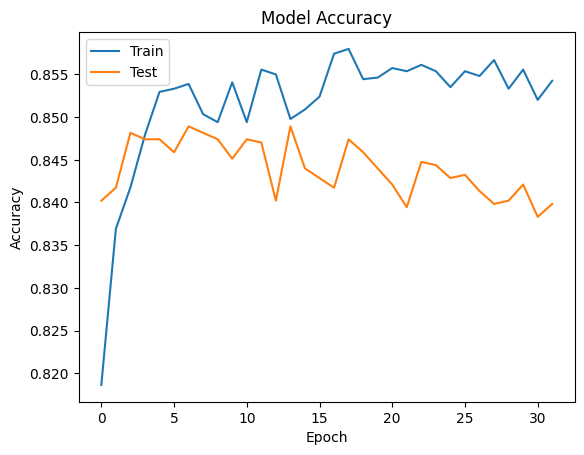

In [71]:
#Sumarize the history for the accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

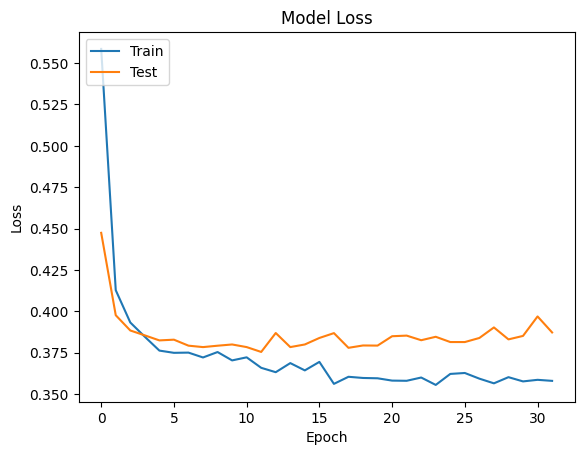

In [72]:
#sumairie the loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

In [73]:
#Making the prediction and evaluation the model
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [74]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1569,   26],
       [ 270,  135]])

In [75]:
#Calculate the accoracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.852

In [76]:
classifier.get_weights()

[array([[ 0.06635179, -0.01955276, -0.03294339, -1.0500282 , -0.1205112 ,
          0.21335672,  0.46663645, -0.12160029, -0.43715757,  0.45870325,
         -0.22177644],
        [-0.2702968 , -0.67587817,  0.21350528, -0.30756485,  0.58927363,
          0.63916683, -0.36269832,  1.0432826 , -1.0625327 , -0.4341126 ,
          0.11583495],
        [ 0.14134505,  0.05880671,  0.04634317,  0.88778687,  0.05030062,
          0.36595622, -0.29429415, -0.04183554, -0.11022291, -0.25468737,
         -0.26523805],
        [ 0.3427348 , -0.79319215, -0.22955176,  1.152628  , -0.13749535,
         -0.32028037, -0.4848224 , -0.09252148,  0.17255192, -0.79037756,
          0.23842856],
        [ 1.53357   ,  0.2811719 ,  0.1484961 , -0.23515259,  1.0494264 ,
          0.33790717,  0.5348668 , -0.7520398 ,  0.08503225, -0.8354569 ,
         -0.04122897],
        [ 0.00903345, -0.26243132, -0.11717857, -0.3533247 ,  0.11870217,
          0.7223386 , -0.5950065 , -0.06567294, -0.26603535,  0.2706000